In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import pickle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns

In [3]:
IMG_SIZE = 224

def load_dataset(base_path):
    X = []
    y = []
    class_names = sorted(os.listdir(base_path))
    for label, cls in enumerate(class_names):
        cls_folder = os.path.join(base_path, cls)
        if not os.path.isdir(cls_folder):
            continue
        for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            # Convert B/W or grayscale to RGB
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y), class_names

In [4]:
dataset_path = "/content/drive/MyDrive/brain-tumor-classification/data/processed/Training"
X, y, class_names = load_dataset(dataset_path)
print("Dataset loaded:", X.shape, y.shape)
print("Classes:", class_names)

Dataset loaded: (2870, 224, 224, 3) (2870,)
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Pixel range: 0 → 255


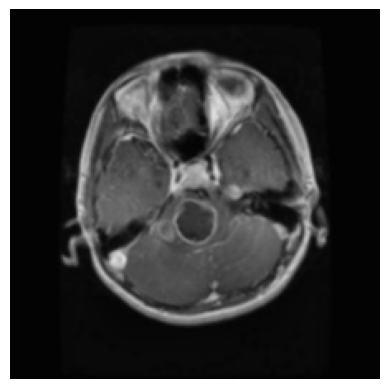

In [5]:
print("Pixel range:", X.min(), "→", X.max())
plt.imshow(X[0])
plt.axis("off")
plt.show()

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42, stratify=y_train_full
)

# Convert y → one-hot
y_train_cat = to_categorical(y_train, num_classes=len(class_names))
y_val_cat = to_categorical(y_val, num_classes=len(class_names))
y_test_cat = to_categorical(y_test, num_classes=len(class_names))

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2324, 224, 224, 3)
Validation: (259, 224, 224, 3)
Test: (287, 224, 224, 3)


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow(X_train, y_train_cat, batch_size=32, shuffle=True)
val_gen = val_datagen.flow(X_val, y_val_cat, batch_size=32)
test_gen = test_datagen.flow(X_test, y_test_cat, batch_size=32)

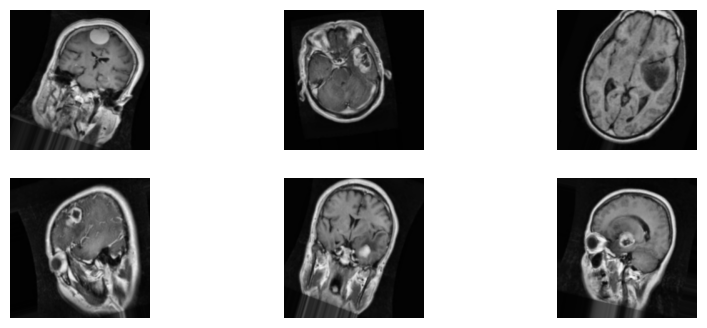

In [8]:
images, labels = next(train_gen)
plt.figure(figsize=(10,4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

In [16]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen
)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 50s 546ms/step - accuracy: 0.2891 - loss: 1.5213 - val_accuracy: 0.3591 - val_loss: 1.2605
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 31s 426ms/step - accuracy: 0.3875 - loss: 1.2953 - val_accuracy: 0.5019 - val_loss: 1.2238
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 31s 420ms/step - accuracy: 0.4200 - loss: 1.2698 - val_accuracy: 0.5598 - val_loss: 1.1910
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 30s 414ms/step - accuracy: 0.4240 - loss: 1.2592 - val_accuracy: 0.5212 - val_loss: 1.1591
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 30s 414ms/step - accuracy: 0.4234 - loss: 1.2454 - val_accuracy: 0.5367 - val_loss: 1.1352
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 448ms/step - accuracy: 0.4676 - loss: 1.2047 - val_accuracy: 0.6023 - val_loss: 1.1033
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 31s 416ms/step - accuracy: 0.4369 - loss: 1.2251 - val_accuracy: 0.5714 - val_loss: 1.0999
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 30s 413ms/step - accuracy: 0.5108 - loss: 1.1602 - 

In [18]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 602ms/step - accuracy: 0.6929 - loss: 0.7286
Test Accuracy: 0.6794425249099731


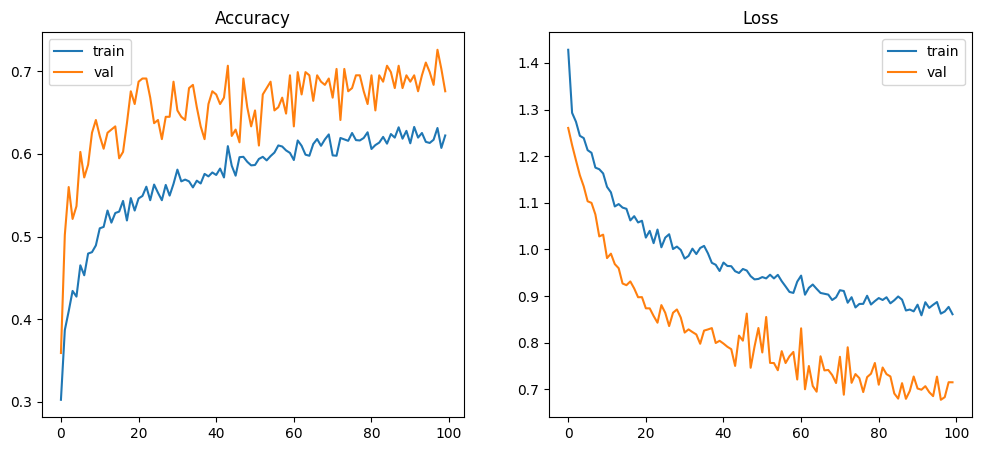

In [19]:
plt.figure(figsize=(12,5))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["train", "val"])
# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [22]:
model_save_path = "/content/drive/MyDrive/brain-tumor-classification/models/ResNet50"
os.makedirs(model_save_path, exist_ok=True)

# Save the entire model as .pkl
model_file = os.path.join(model_save_path, "resnet50_brain_tumor_model.pkl")
with open(model_file, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved successfully at: {model_file}")

# Also save as .h5 for better compatibility
h5_file = os.path.join(model_save_path, "resnet50_brain_tumor_model.h5")
model.save(h5_file)
print(f"Model also saved as .h5 at: {h5_file}")

# Save class names
class_names_file = os.path.join(model_save_path, "class_names.pkl")
with open(class_names_file, 'wb') as f:
    pickle.dump(class_names, f)
print(f"Class names saved at: {class_names_file}")

Model saved successfully at: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50/resnet50_brain_tumor_model.pkl
Model also saved as .h5 at: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50/resnet50_brain_tumor_model.h5
Class names saved at: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50/class_names.pkl


In [23]:
X_test_normalized = X_test / 255.0  # Normalize same as test_gen
y_pred_probs = model.predict(X_test_normalized, batch_size=32, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test  # Original labels (not one-hot)

print("\nPredictions shape:", y_pred.shape)
print("True labels shape:", y_true.shape)
print("Sample predictions:", y_pred[:10])
print("Sample true labels:", y_true[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 531ms/step

Predictions shape: (287,)
True labels shape: (287,)
Sample predictions: [0 0 0 3 1 3 0 2 0 1]
Sample true labels: [0 0 1 0 3 3 0 2 1 2]


In [24]:
print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)

# Overall Accuracy - This should match Keras evaluation
overall_accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Keras Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Difference: {abs(overall_accuracy - acc):.6f}")

# Overall Precision, Recall, F1-Score
overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall = recall_score(y_true, y_pred, average='weighted')
overall_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nOverall Precision: {overall_precision:.4f}")
print(f"Overall Recall: {overall_recall:.4f}")
print(f"Overall F1-Score: {overall_f1:.4f}")

# Macro averages (unweighted)
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f"\nMacro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")


OVERALL METRICS
Overall Accuracy: 0.6794 (67.94%)
Keras Test Accuracy: 0.6794 (67.94%)
Difference: 0.000000

Overall Precision: 0.7063
Overall Recall: 0.6794
Overall F1-Score: 0.6486

Macro Precision: 0.7092
Macro Recall: 0.6698
Macro F1-Score: 0.6503


In [25]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT (CLASS-WISE METRICS)")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)


CLASSIFICATION REPORT (CLASS-WISE METRICS)
                  precision    recall  f1-score   support

    glioma_tumor     0.7143    0.7831    0.7471        83
meningioma_tumor     0.7742    0.2927    0.4248        82
        no_tumor     0.7273    0.6154    0.6667        39
 pituitary_tumor     0.6212    0.9880    0.7628        83

        accuracy                         0.6794       287
       macro avg     0.7092    0.6698    0.6503       287
    weighted avg     0.7063    0.6794    0.6486       287



In [26]:
print("\n" + "="*60)
print("CLASS-WISE DETAILED METRICS")
print("="*60)

for i, class_name in enumerate(class_names):
    # Get indices where true label is this class
    class_indices = np.where(y_true == i)[0]

    if len(class_indices) > 0:
        # Get predictions for this class
        class_predictions = y_pred[class_indices]

        # Calculate metrics
        class_correct = np.sum(class_predictions == i)
        class_total = len(class_indices)
        class_accuracy = class_correct / class_total

        # True Positives, False Positives, False Negatives
        tp = class_correct
        fp = np.sum(y_pred == i) - tp  # Predicted as this class but actually not
        fn = class_total - tp  # Actually this class but predicted as other

        # Precision and Recall for this class
        class_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        class_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0

        print(f"\n{class_name}:")
        print(f"  Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")
        print(f"  Correct: {class_correct}/{class_total}")
        print(f"  Precision: {class_precision:.4f}")
        print(f"  Recall: {class_recall:.4f}")
        print(f"  F1-Score: {class_f1:.4f}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}")


CLASS-WISE DETAILED METRICS

glioma_tumor:
  Accuracy: 0.7831 (78.31%)
  Correct: 65/83
  Precision: 0.7143
  Recall: 0.7831
  F1-Score: 0.7471
  TP: 65, FP: 26, FN: 18

meningioma_tumor:
  Accuracy: 0.2927 (29.27%)
  Correct: 24/82
  Precision: 0.7742
  Recall: 0.2927
  F1-Score: 0.4248
  TP: 24, FP: 7, FN: 58

no_tumor:
  Accuracy: 0.6154 (61.54%)
  Correct: 24/39
  Precision: 0.7273
  Recall: 0.6154
  F1-Score: 0.6667
  TP: 24, FP: 9, FN: 15

pituitary_tumor:
  Accuracy: 0.9880 (98.80%)
  Correct: 82/83
  Precision: 0.6212
  Recall: 0.9880
  F1-Score: 0.7628
  TP: 82, FP: 50, FN: 1



CONFUSION MATRIX

Raw Confusion Matrix:
[[65  4  0 14]
 [25 24  9 24]
 [ 1  2 24 12]
 [ 0  1  0 82]]

Rows = True Labels, Columns = Predicted Labels


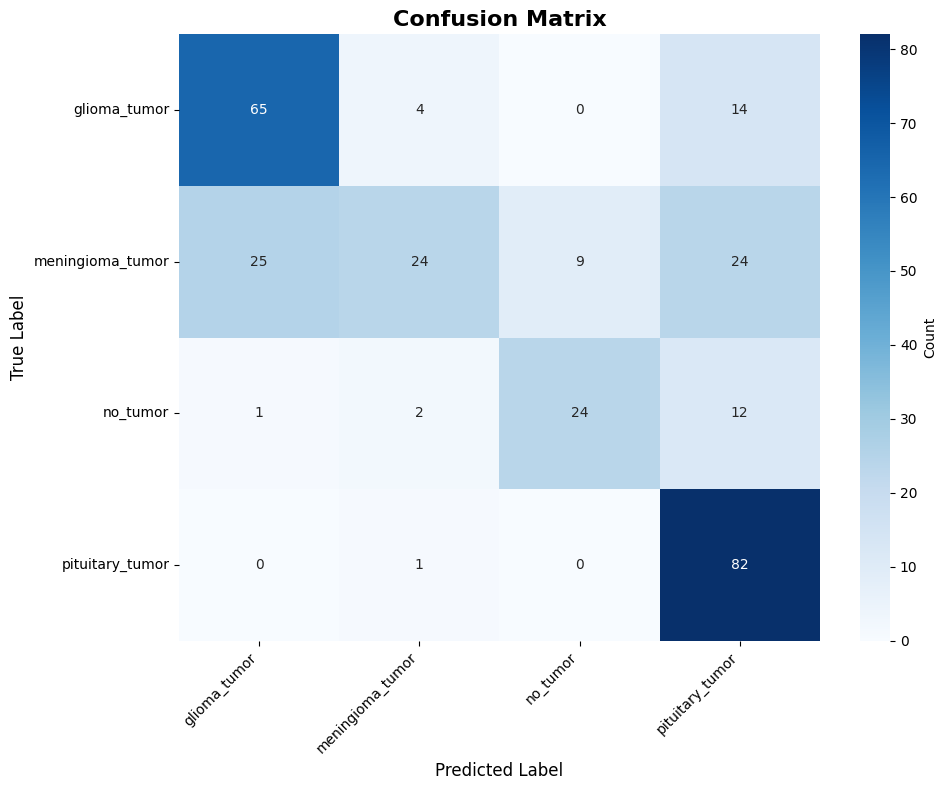

In [27]:
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_true, y_pred)
print("\nRaw Confusion Matrix:")
print(cm)
print("\nRows = True Labels, Columns = Predicted Labels")

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Normalized Confusion Matrix (by row):
[[0.78313253 0.04819277 0.         0.1686747 ]
 [0.30487805 0.29268293 0.1097561  0.29268293]
 [0.02564103 0.05128205 0.61538462 0.30769231]
 [0.         0.01204819 0.         0.98795181]]


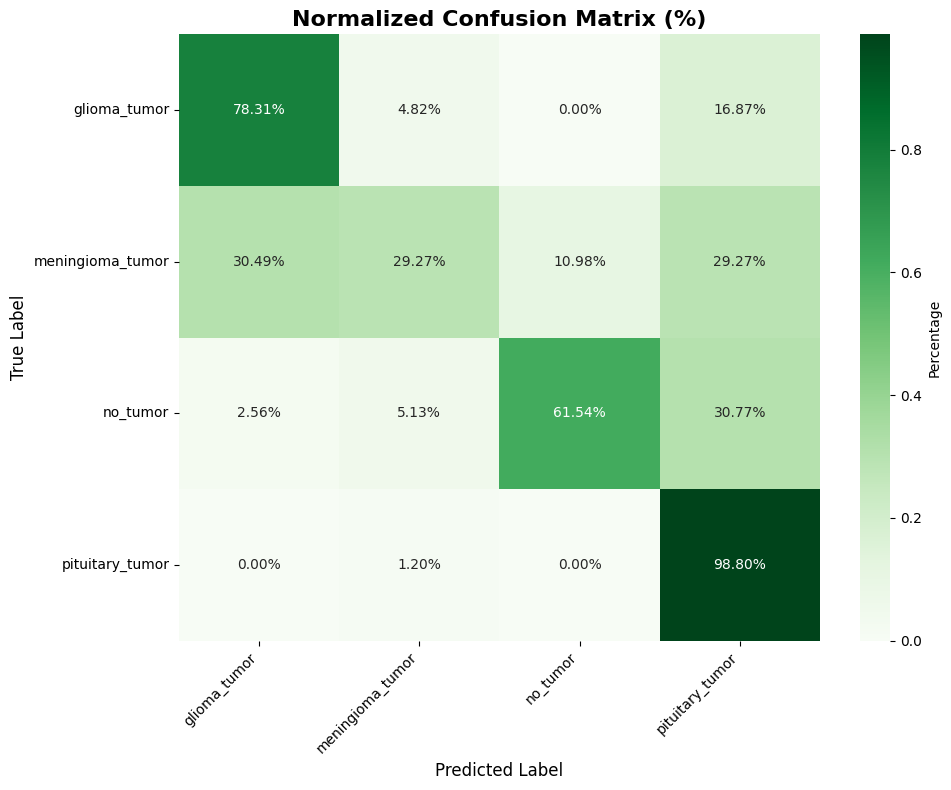

In [28]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("\nNormalized Confusion Matrix (by row):")
print(cm_normalized)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix (%)', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

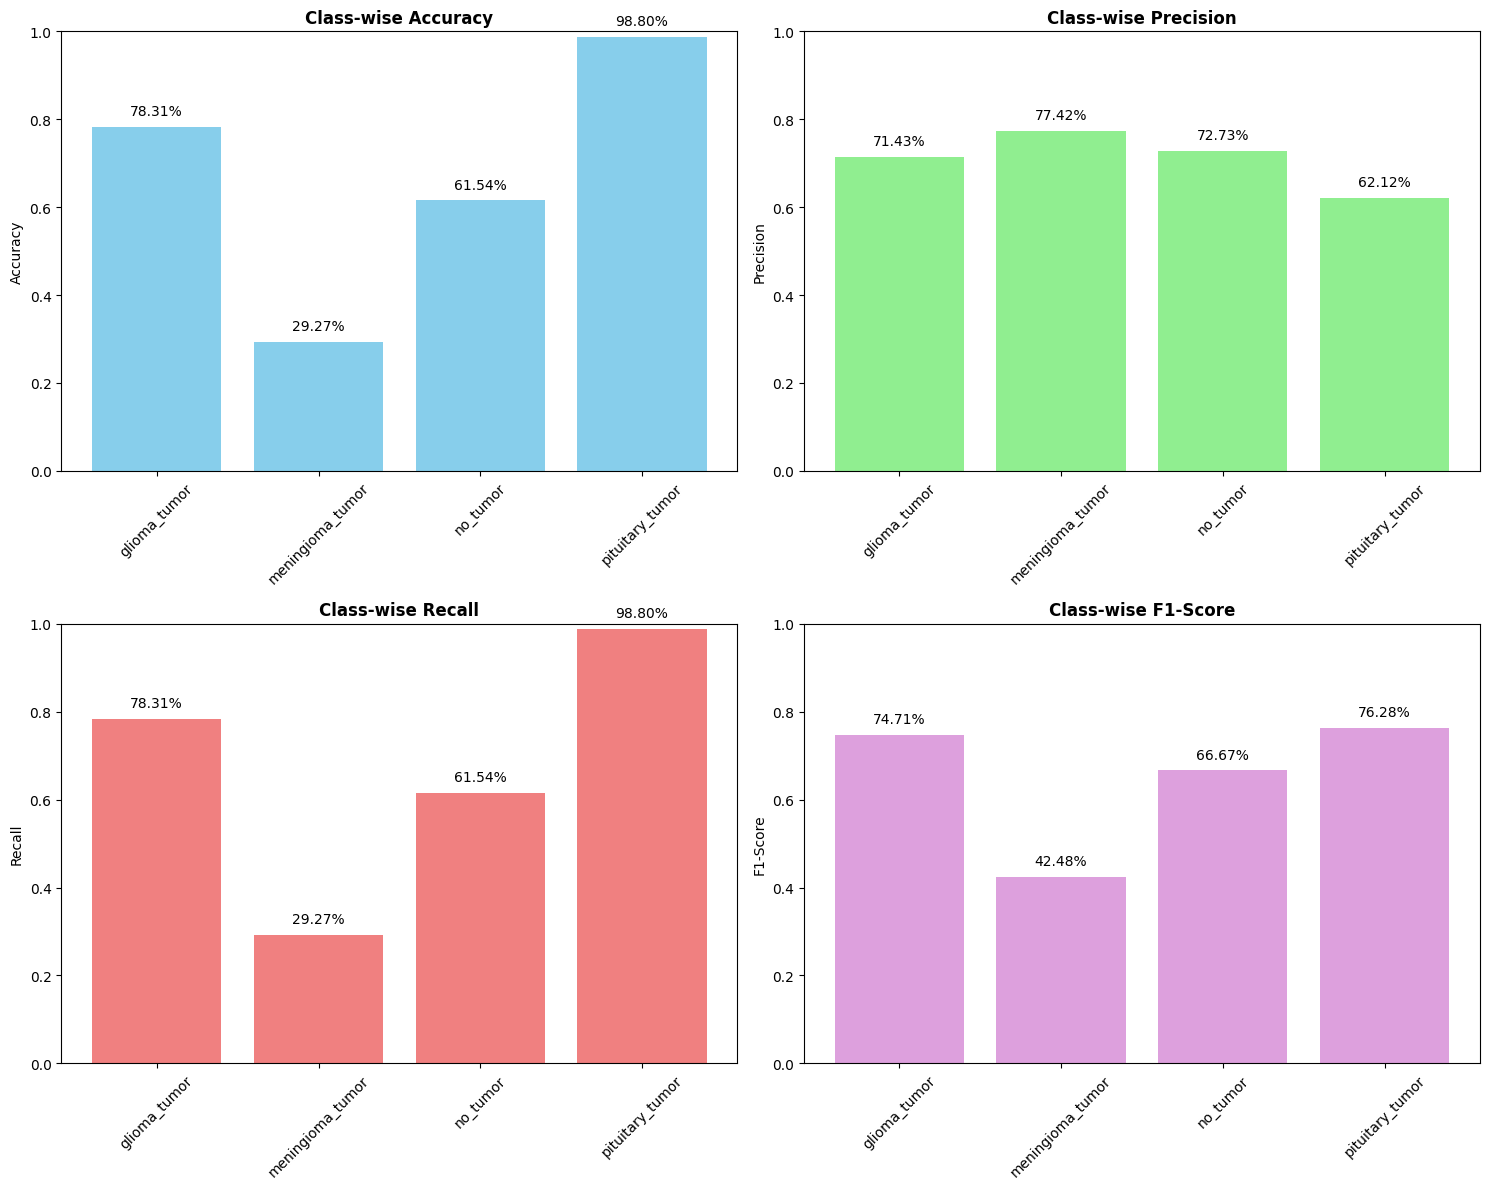

In [29]:
class_accuracies = []
class_precisions = []
class_recalls = []
class_f1_scores = []

for i in range(len(class_names)):
    class_indices = np.where(y_true == i)[0]
    if len(class_indices) > 0:
        class_predictions = y_pred[class_indices]
        class_acc = np.sum(class_predictions == i) / len(class_indices)

        tp = np.sum(class_predictions == i)
        fp = np.sum(y_pred == i) - tp
        fn = len(class_indices) - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        class_accuracies.append(class_acc)
        class_precisions.append(precision)
        class_recalls.append(recall)
        class_f1_scores.append(f1)

# Plot per-class metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0, 0].bar(class_names, class_accuracies, color='skyblue')
axes[0, 0].set_title('Class-wise Accuracy', fontweight='bold')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

# Precision
axes[0, 1].bar(class_names, class_precisions, color='lightgreen')
axes[0, 1].set_title('Class-wise Precision', fontweight='bold')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_precisions):
    axes[0, 1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

# Recall
axes[1, 0].bar(class_names, class_recalls, color='lightcoral')
axes[1, 0].set_title('Class-wise Recall', fontweight='bold')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_recalls):
    axes[1, 0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

# F1-Score
axes[1, 1].bar(class_names, class_f1_scores, color='plum')
axes[1, 1].set_title('Class-wise F1-Score', fontweight='bold')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_f1_scores):
    axes[1, 1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [30]:
metrics_file = os.path.join(model_save_path, "model_metrics.txt")
with open(metrics_file, 'w') as f:
    f.write("="*60 + "\n")
    f.write("BRAIN TUMOR CLASSIFICATION - MODEL EVALUATION METRICS\n")
    f.write("="*60 + "\n\n")

    f.write("="*60 + "\n")
    f.write("OVERALL METRICS\n")
    f.write("="*60 + "\n")
    f.write(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)\n")
    f.write(f"Keras Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
    f.write(f"Difference: {abs(overall_accuracy - acc):.6f}\n\n")

    f.write(f"Weighted Precision: {overall_precision:.4f}\n")
    f.write(f"Weighted Recall: {overall_recall:.4f}\n")
    f.write(f"Weighted F1-Score: {overall_f1:.4f}\n\n")

    f.write(f"Macro Precision: {macro_precision:.4f}\n")
    f.write(f"Macro Recall: {macro_recall:.4f}\n")
    f.write(f"Macro F1-Score: {macro_f1:.4f}\n\n")

    f.write("="*60 + "\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("="*60 + "\n")
    f.write(report)
    f.write("\n")

    f.write("="*60 + "\n")
    f.write("CLASS-WISE DETAILED METRICS\n")
    f.write("="*60 + "\n")
    for i, class_name in enumerate(class_names):
        class_indices = np.where(y_true == i)[0]
        if len(class_indices) > 0:
            class_predictions = y_pred[class_indices]
            class_correct = np.sum(class_predictions == i)
            class_total = len(class_indices)
            class_accuracy = class_correct / class_total

            tp = class_correct
            fp = np.sum(y_pred == i) - tp
            fn = class_total - tp

            class_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            class_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0

            f.write(f"\n{class_name}:\n")
            f.write(f"  Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)\n")
            f.write(f"  Correct: {class_correct}/{class_total}\n")
            f.write(f"  Precision: {class_precision:.4f}\n")
            f.write(f"  Recall: {class_recall:.4f}\n")
            f.write(f"  F1-Score: {class_f1:.4f}\n")
            f.write(f"  TP: {tp}, FP: {fp}, FN: {fn}\n")

    f.write("\n")
    f.write("="*60 + "\n")
    f.write("CONFUSION MATRIX\n")
    f.write("="*60 + "\n")
    f.write("Rows = True Labels, Columns = Predicted Labels\n\n")
    f.write(str(cm))
    f.write("\n\n")
    f.write("Normalized Confusion Matrix:\n")
    f.write(str(cm_normalized))

print(f"\nAll metrics saved to: {metrics_file}")


All metrics saved to: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50/model_metrics.txt


In [31]:
print("\n" + "="*60)
print("LOADING SAVED MODEL AND MAKING PREDICTIONS")
print("="*60)

# Load the model
with open(model_file, 'rb') as f:
    loaded_model = pickle.load(f)
print("Model loaded successfully!")

# Load class names
with open(class_names_file, 'rb') as f:
    loaded_class_names = pickle.load(f)
print("Class names loaded:", loaded_class_names)


LOADING SAVED MODEL AND MAKING PREDICTIONS
Model loaded successfully!
Class names loaded: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [32]:
def predict_image(model, img_array, class_names):
    """
    Predict the class of a single image

    Args:
        model: Trained model
        img_array: Image array (already resized to 224x224)
        class_names: List of class names

    Returns:
        predicted_class, confidence, all_probabilities
    """
    # Ensure image is in correct format
    if img_array.max() > 1.0:
        img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]

    return class_names[predicted_class_idx], confidence, predictions[0]

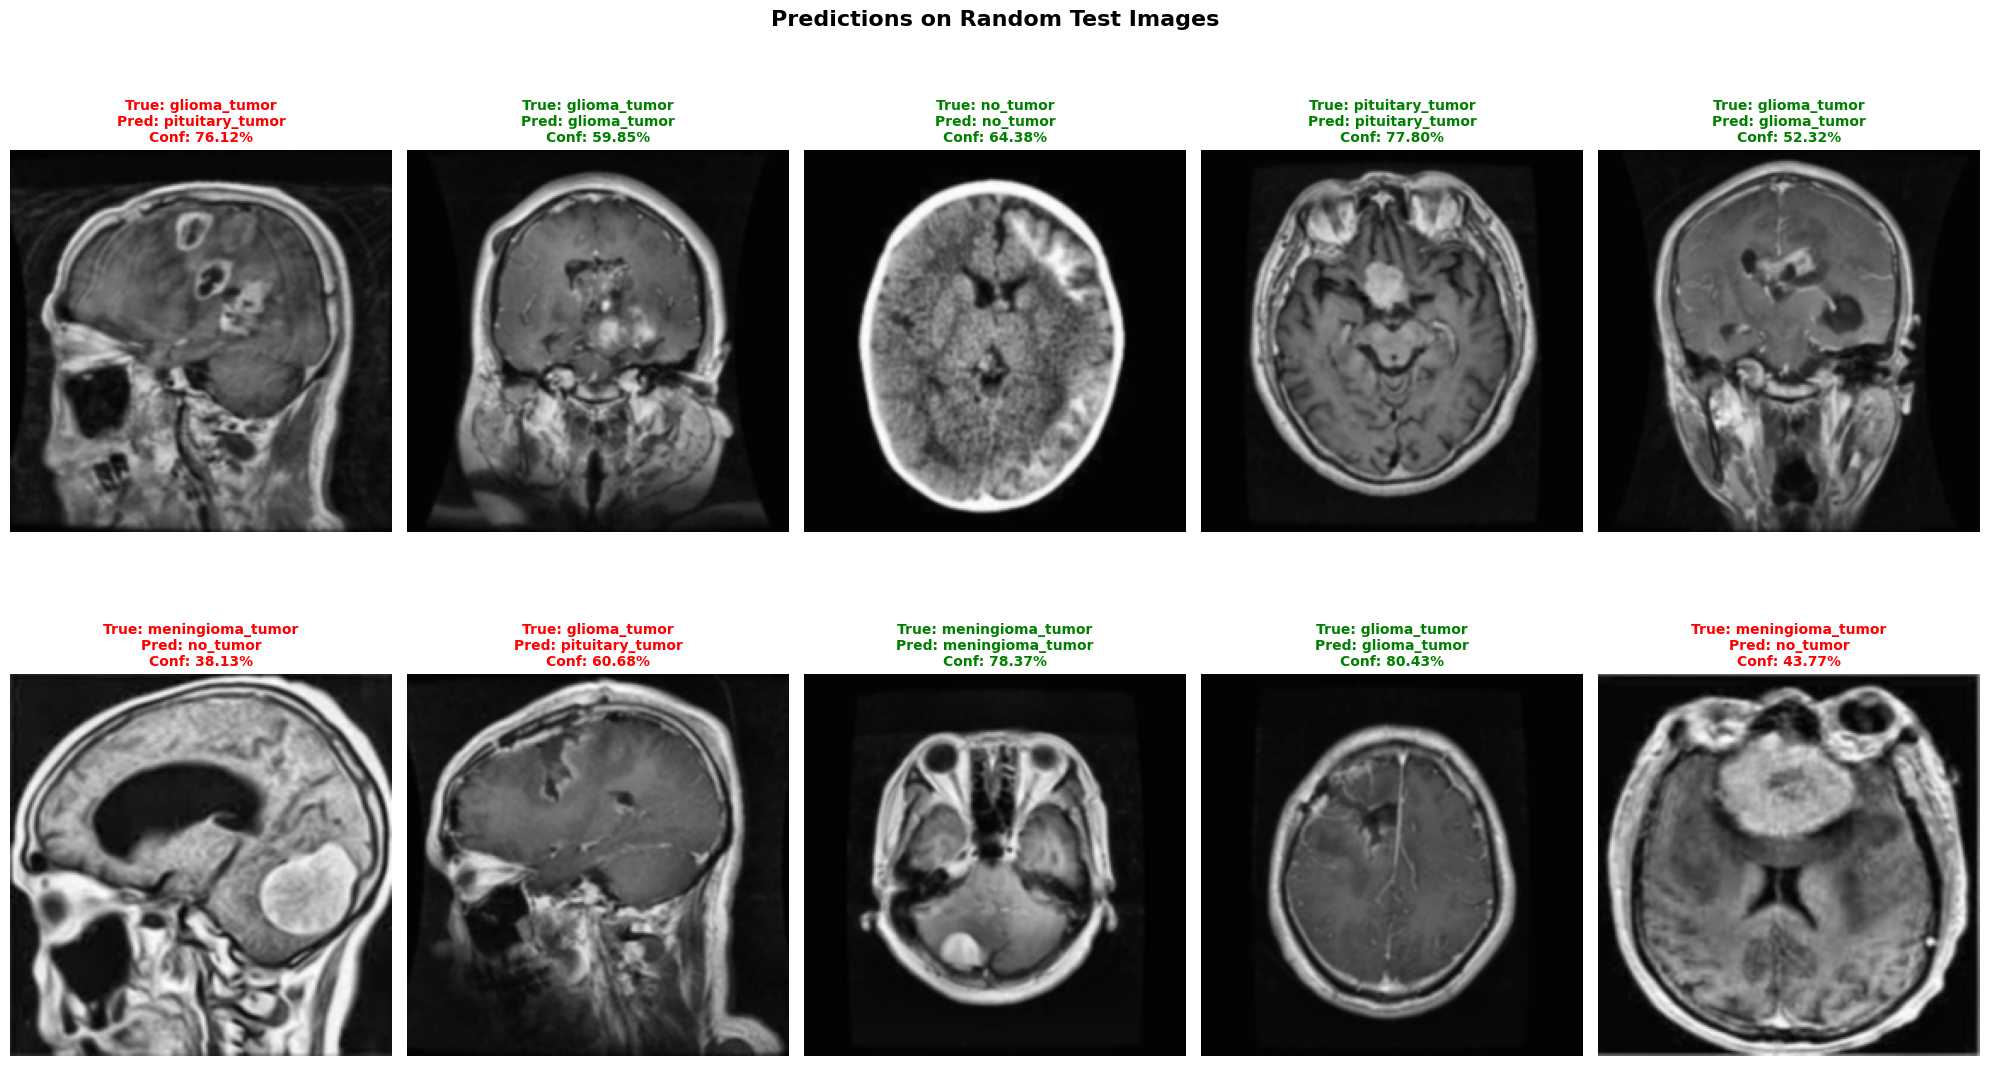

In [33]:
num_samples = 10
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(20, 12))
for idx, i in enumerate(random_indices):
    img = X_test[i]
    true_label = class_names[y_test[i]]

    # Predict
    pred_class, confidence, all_probs = predict_image(loaded_model, img, loaded_class_names)

    # Plot
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.axis('off')

    # Color: green if correct, red if wrong
    color = 'green' if pred_class == true_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_class}\nConf: {confidence:.2%}',
              fontsize=10, color=color, fontweight='bold')

plt.suptitle('Predictions on Random Test Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()